# 02. Baseline: Portugal Crop Classification

Цель ноутбука: подготовить признаки из Portugal raw data и обучить простую baseline-модель без feature engineering.

Модель: линейная logistic baseline через `SGDClassifier(loss="log_loss")`. Это простая модель из scikit-learn, которая обучает линейную логистическую классификацию стохастическим градиентным спуском и лучше подходит для широких временных признаков, чем тяжёлая full-batch LogisticRegression.

## Метрики

Основная метрика: **macro F1**, потому что классы культур сильно несбалансированы и нужно учитывать качество на редких культурах.

Дополнительные метрики:

- `accuracy` — интуитивная доля правильных ответов, но чувствительна к дисбалансу;
- `balanced accuracy` — средний recall по классам, полезен при дисбалансе;
- `classification_report` — precision/recall/F1 по классам.

In [1]:
from pathlib import Path
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "portugal" / "raw_data" / "Portugal.parquet"
PROCESSED_PATH = ROOT / "data" / "processed" / "portugal_baseline_dataset.npz"
MODEL_PATH = ROOT / "models" / "portugal_sgd_logistic_baseline.joblib"
IMAGES_DIR = ROOT / "report" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
assert RAW_PATH.exists(), f"File not found: {RAW_PATH}. Run: python -m src.raw_portugal extract"

## Загрузка и очистка

Для baseline используем только исходные временные ряды. Служебные поля удаляются из признаков:

- `parcel_id` — идентификатор поля, может привести к утечке;
- `EC_hcat_c` — target;
- `EC_hcat_n` — текстовое имя target;
- `nuts1`, `nuts2`, `nuts3` — региональные коды, не спутниковые временные признаки.

In [2]:
df = pd.read_parquet(RAW_PATH)
date_pattern = re.compile(r"^\d{4}-\d{2}-\d{2}$")
date_cols = [column for column in df.columns if date_pattern.match(str(column))]

print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Date columns: {len(date_cols)}")
print(f"Target classes before filtering: {df['EC_hcat_c'].nunique():,}")
print(f"Duplicate parcel_id: {df['parcel_id'].duplicated().sum():,}")

Raw shape: 100,000 rows x 225 columns
Date columns: 219
Target classes before filtering: 79
Duplicate parcel_id: 0


In [3]:
# Для честного stratified train/val/test split оставляем классы, где минимум 3 объекта.
# Иначе класс невозможно одновременно представить в train, validation и test.
MIN_CLASS_COUNT = 3
class_counts = df["EC_hcat_c"].value_counts()
kept_classes = class_counts[class_counts >= MIN_CLASS_COUNT].index
work = df[df["EC_hcat_c"].isin(kept_classes)].copy()

print(f"Rows after rare-class filtering: {len(work):,} / {len(df):,}")
print(f"Classes after filtering: {work['EC_hcat_c'].nunique():,}")
print(f"Dropped rare classes: {(class_counts < MIN_CLASS_COUNT).sum():,}")

Rows after rare-class filtering: 99,983 / 100,000
Classes after filtering: 66
Dropped rare classes: 13


## Подготовка признаков

Каждая дата содержит список из 13 Sentinel-2 значений. Для baseline без feature engineering просто разворачиваем исходный временной ряд в плоский вектор:

`2021-01-01_band_00`, ..., `2021-12-30_band_12`.

Если наблюдение отсутствует (`None`), ставим нулевой 13-мерный вектор. Это простая обработка пропусков, а не создание новых признаков.

In [4]:
def flatten_timeseries(frame: pd.DataFrame, dates: list[str], band_count: int = 13) -> tuple[np.ndarray, np.ndarray]:
    feature_names = np.array(
        [f"{date}_band_{band_idx:02d}" for date in dates for band_idx in range(band_count)],
        dtype=str,
    )
    x = np.zeros((len(frame), len(feature_names)), dtype=np.float32)
    for date_idx, column in enumerate(dates):
        values = frame[column]
        mask = values.notna().to_numpy()
        if not mask.any():
            continue
        observed = np.asarray(values.loc[mask].tolist(), dtype=np.float32)
        start = date_idx * band_count
        x[mask, start:start + band_count] = observed
    return x, feature_names

X, feature_names = flatten_timeseries(work, date_cols)
y = work["EC_hcat_c"].astype(str).to_numpy()

print(f"X shape: {X.shape[0]:,} rows x {X.shape[1]:,} features")
print(f"y shape: {y.shape}")
print(f"Feature example: {feature_names[:5].tolist()} ... {feature_names[-5:].tolist()}")

X shape: 99,983 rows x 2,847 features
y shape: (99983,)
Feature example: ['2021-01-01_band_00', '2021-01-01_band_01', '2021-01-01_band_02', '2021-01-01_band_03', '2021-01-01_band_04'] ... ['2021-12-30_band_08', '2021-12-30_band_09', '2021-12-30_band_10', '2021-12-30_band_11', '2021-12-30_band_12']


## Train/Validation/Test split

Разбиение: 60% train, 20% validation, 20% test.

Data leakage избегается так: одна строка соответствует одному полю, и все даты этого поля остаются внутри одной части split. Мы не делим временной ряд одного поля между train и test.

In [5]:
indices = np.arange(len(y))
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y[train_val_idx],
)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Train: {X_train.shape}, classes={len(np.unique(y_train))}")
print(f"Validation: {X_val.shape}, classes={len(np.unique(y_val))}")
print(f"Test: {X_test.shape}, classes={len(np.unique(y_test))}")

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    PROCESSED_PATH,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)
print(f"Saved prepared dataset to {PROCESSED_PATH}")

Train: (59989, 2847), classes=66
Validation: (19997, 2847), classes=66
Test: (19997, 2847), classes=63


Saved prepared dataset to /Users/yudintsev/PycharmProjects/hseml-group-project-yud7-2/data/processed/portugal_baseline_dataset.npz


,split,rows,classes
0,train,59989,66
1,validation,19997,66
2,test,19997,63


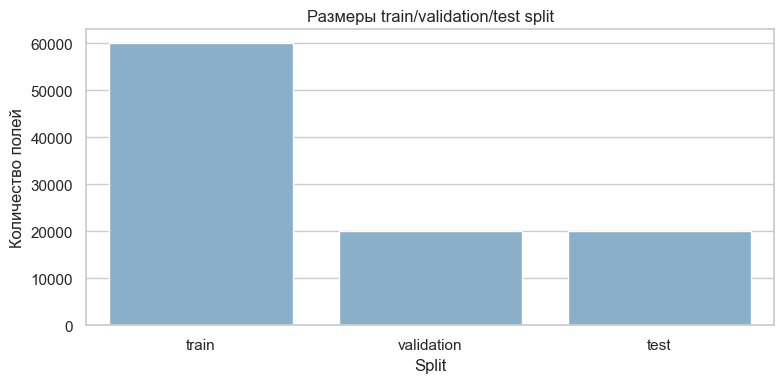

In [6]:
split_counts = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "classes": [len(np.unique(y_train)), len(np.unique(y_val)), len(np.unique(y_test))],
})
display(split_counts)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=split_counts, x="split", y="rows", ax=ax, color="#80b1d3")
ax.set_title("Размеры train/validation/test split")
ax.set_xlabel("Split")
ax.set_ylabel("Количество полей")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "baseline_split_sizes.png", dpi=160, bbox_inches="tight")
plt.show()

## Наивный baseline

Перед обучаемой моделью считаем `DummyClassifier(strategy="most_frequent")`: он всегда предсказывает самый частый класс. Это важная нижняя планка для accuracy, потому что датасет сильно несбалансирован.

In [7]:
dummy_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy_model.fit(X_train, y_train)


def evaluate_model(model, model_name: str, split_name: str, x: np.ndarray, y_true: np.ndarray) -> dict[str, float | str]:
    y_pred = model.predict(x)
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

dummy_metrics = pd.DataFrame([
    evaluate_model(dummy_model, "most_frequent_dummy", "validation", X_val, y_val),
    evaluate_model(dummy_model, "most_frequent_dummy", "test", X_test, y_test),
])
display(dummy_metrics)

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,most_frequent_dummy,validation,0.295944,0.015152,0.00692,0.135165
1,most_frequent_dummy,test,0.295944,0.015873,0.00725,0.135165


## Baseline-модель

Используем простую линейную модель без feature engineering:

- `StandardScaler` — масштабирование исходных числовых признаков;
- `SGDClassifier(loss="log_loss")` — линейная логистическая классификация;
- `class_weight="balanced"` — компенсация дисбаланса классов.

In [8]:
model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            SGDClassifier(
                loss="log_loss",
                class_weight="balanced",
                alpha=1e-4,
                max_iter=1_000,
                tol=1e-3,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Saved model to {MODEL_PATH}")

Saved model to /Users/yudintsev/PycharmProjects/hseml-group-project-yud7-2/models/portugal_sgd_logistic_baseline.joblib


In [9]:
sgd_metrics = pd.DataFrame([
    evaluate_model(model, "sgd_logistic_baseline", "validation", X_val, y_val),
    evaluate_model(model, "sgd_logistic_baseline", "test", X_test, y_test),
])
metrics = pd.concat([dummy_metrics, sgd_metrics], ignore_index=True)
display(metrics)

metrics.to_csv(ROOT / "report" / "baseline_metrics.csv", index=False)
print("Validation classification report for SGD logistic baseline:")
print(classification_report(y_val, model.predict(X_val), zero_division=0))
print("Test classification report for SGD logistic baseline:")
print(classification_report(y_test, model.predict(X_test), zero_division=0))

/Users/yudintsev/PycharmProjects/hseml-group-project-yud7-2/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,most_frequent_dummy,validation,0.295944,0.015152,0.006920,0.135165
1,most_frequent_dummy,test,0.295944,0.015873,0.007250,0.135165
2,sgd_logistic_baseline,validation,0.290794,0.246158,0.136226,0.288386
3,sgd_logistic_baseline,test,0.287993,0.220194,0.125841,0.285620


Validation classification report for SGD logistic baseline:


              precision    recall  f1-score   support

  3301010100       0.12      0.18      0.14        38
  3301010300       0.08      0.21      0.11        57
  3301010400       0.16      0.29      0.21        14
  3301010500       0.17      0.05      0.08       187
  3301010600       0.35      0.58      0.44       895
  3301010700       0.84      0.80      0.82        54
  3301010800       0.02      0.17      0.04         6
  3301010900       0.01      0.05      0.02        19
  3301019900       0.05      0.28      0.09        25
  3301020100       0.00      0.00      0.00        38
  3301020200       0.00      0.00      0.00         3
  3301020600       0.00      0.00      0.00         3
  3301020700       0.00      0.00      0.00        13
  3301030000       0.09      0.21      0.13       105
  3301040000       0.00      0.00      0.00         3
  3301060500       0.40      1.00      0.57         2
  3301061200       0.00      0.00      0.00         2
  3301061228       0.00    

              precision    recall  f1-score   support

  3301010100       0.06      0.08      0.07        38
  3301010300       0.13      0.36      0.19        56
  3301010400       0.06      0.07      0.06        14
  3301010500       0.15      0.04      0.07       187
  3301010600       0.36      0.56      0.44       895
  3301010700       0.89      0.87      0.88        54
  3301010800       0.00      0.00      0.00         6
  3301010900       0.03      0.11      0.04        19
  3301019900       0.10      0.52      0.17        25
  3301020100       0.04      0.08      0.06        38
  3301020200       0.00      0.00      0.00         3
  3301020600       0.00      0.00      0.00         4
  3301020700       0.02      0.08      0.03        13
  3301030000       0.06      0.12      0.08       105
  3301040000       0.06      0.33      0.10         3
  3301060500       0.00      0.00      0.00         2
  3301061200       0.00      0.00      0.00         2
  3301061228       0.00    

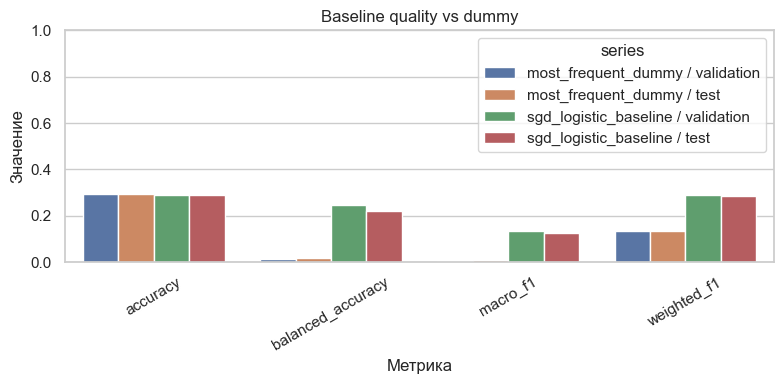

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_metrics = metrics.melt(id_vars=["model", "split"], var_name="metric", value_name="value")
plot_metrics["series"] = plot_metrics["model"] + " / " + plot_metrics["split"]
sns.barplot(data=plot_metrics, x="metric", y="value", hue="series", ax=ax)
ax.set_title("Baseline quality vs dummy")
ax.set_xlabel("Метрика")
ax.set_ylabel("Значение")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
fig.savefig(IMAGES_DIR / "baseline_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

## Вывод baseline

- `DummyClassifier(strategy="most_frequent")` показывает нижнюю планку: из-за дисбаланса он получает заметную accuracy, но почти нулевой macro F1.
- Обучаемый baseline построен на прямом разворачивании исходных временных признаков `date x band` без доменного feature engineering.
- Основную метрику выбираем `macro F1`, потому что классы несбалансированы; accuracy смотрим только как дополнительную справочную метрику.
- Split сделан по полям, поэтому временные наблюдения одного поля не попадают одновременно в train и test.
- Следующие эксперименты для полного проекта: RandomForest, Gradient Boosting / LightGBM, PCA/SVD для уменьшения размерности, агрегации временных рядов и NDVI/другие индексы.